In [304]:
# #block 1
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

In [305]:
import torch
import gc
gc.collect()
torch.cuda.empty_cache()
print("VRAM completely flushed and cleared!")

VRAM completely flushed and cleared!


In [306]:
#block 2

import os
import numpy as np
from torchvision import models
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, Dataset
import matplotlib.pyplot as plt
from torchvision import transforms
import pandas as pd
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import f1_score
import copy

In [307]:
import random
import warnings

warnings.filterwarnings('ignore')


GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
os.environ['PYTHONHASHSEED'] = str(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)


if torch.cuda.is_available():
    torch.cuda.manual_seed(GLOBAL_SEED)
    torch.cuda.manual_seed_all(GLOBAL_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


batch_size = 32

print(f"Block 3 Configured! Batch Size set to {batch_size}.")

Block 3 Configured! Batch Size set to 32.


In [308]:
# Block 4
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

#make a main class
class TestImageDataset(Dataset):
    #constructor
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        # Enforce alphanumeric sorting to prevent file-index mismatch bugs in the final CSV
        self.image_files = sorted([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
        self.transform = transform

    
    #finds the number of image files sitting
    def __len__(self):
        return len(self.image_files)

    
    #specific integer index and runs it in the cpu to fetch samples for gpu
    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.folder_path, img_name)
        image = Image.open(img_path).convert("RGB")  # Ensure RGB format
        #runs the transformations and converts image to pytorch flow tensor
        if self.transform:
            image = self.transform(image)
        return image, img_name  # Return image and file name for reference

In [309]:
# Block 5
from torchvision import transforms

# EfficientNet V2 requires Bicubic interpolation for peak feature retention
interpolation_mode = transforms.InterpolationMode.BICUBIC

train_transforms = transforms.Compose([
    # 1. Base scaling and zooming (Fixes building/street overlap)
    transforms.Resize((400, 400), interpolation=interpolation_mode),
    transforms.RandomResizedCrop(384, scale=(0.75, 1.0), ratio=(0.75, 1.33), interpolation=interpolation_mode),
    
    # 2. removing vertical flip by trial and error
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=(-12, 12), interpolation=interpolation_mode),
    
    # 3. Texture forcing (Fixes grayscale)
    transforms.RandomGrayscale(p=0.2),
    
    # 4. Color & Focus Corruptions (Weird hue shifts and blurry test images!)
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.15),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
    
    # 5. Tensor conversion
    transforms.ToTensor(),
    
    # 6. Advanced Regularization
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.1), ratio=(0.3, 3.3), value='random'),
    
    # 7. Standard ImageNet Normalization
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation transforms must remain perfectly clean to measure true accuracy
val_transforms = transforms.Compose([
    transforms.Resize((384, 384), interpolation=interpolation_mode),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Block 5 Configured! transformations done.")

Block 5 Configured! transformations done.


In [310]:
# Block 6
test_val_transforms = transforms.Compose([
    #changing the window size so it learns the texture
    transforms.Resize((384, 384), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

In [311]:
# block 7
train_directory = '/kaggle/input/datasets/cartoonduck/dataset/train'
# Load the training directory twice to keep training and validation completely isolated
full_train_dataset = ImageFolder(train_directory, transform=train_transforms)
full_val_dataset = ImageFolder(train_directory, transform=test_val_transforms)

# 1. Create a mathematically locked, random index map using a fixed seed
dataset_size = len(full_train_dataset)
indices = torch.randperm(dataset_size, generator=torch.Generator().manual_seed(42)).tolist()
train_size = int(0.8 * dataset_size)

# 2. Slice into exclusive subsets (Importing Subset inline to fix the NameError cleanly)
from torch.utils.data import Subset
train_subset = Subset(full_train_dataset, indices[:train_size])
val_subset = Subset(full_val_dataset, indices[train_size:])

# 3. Create high-speed data streams for the dual T4 GPUs (batch_size=64 is from Block 3)
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print(f"Block 7 Complete: {len(train_subset)} Train images | {len(val_subset)} Val images split cleanly.")

Block 7 Complete: 11227 Train images | 2807 Val images split cleanly.


In [312]:
# block 8
# Loading the test dataset
test_directory = '/kaggle/input/datasets/cartoonduck/dataset/test'
test_dataset = TestImageDataset(test_directory, transform=test_val_transforms)

# 1. Build the final test loader stream for the dual T4 GPUs
# shuffle=False is critical so your predictions line up perfectly with your final submission rows
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print(f"Block 8 Complete: Test stream initialized with {len(test_dataset)} images.")

Block 8 Complete: Test stream initialized with 3000 images.


In [313]:
# Block 9
# 1. Download the pre-trained state-of-the-art EfficientNet V2 S model
import torchvision
model = torchvision.models.efficientnet_v2_s(weights=torchvision.models.EfficientNet_V2_S_Weights.DEFAULT)

# 2. Extract the number of incoming connection features to the classification head
in_features = model.classifier[1].in_features

# 3. Fine-tune the final linear layer to map perfectly to your 6 landscape categories
model.classifier[1] = nn.Linear(in_features, 6)

print(f"Block 9 Complete: EfficientNet V2 S model loaded cleanly with {in_features} input features.")

Block 9 Complete: EfficientNet V2 S model loaded cleanly with 1280 input features.


In [314]:
# Block 10
# Print dataset splits to verify the Data Engineering step is correct
print(f"Training images subset size: {len(train_subset)}")
print(f"Validation images subset size: {len(val_subset)}")

Training images subset size: 11227
Validation images subset size: 2807


In [315]:
# Block 11
# Verify the existing high-speed data loaders are mapped correctly
print(f"Data loaders ready: {len(train_loader)} training batches | {len(val_loader)} validation batches")

Data loaders ready: 351 training batches | 88 validation batches


In [316]:
# Block 12
# Verify the final high-speed test loader stream is locked and ready
print(f"Test loader verified: {len(test_loader)} batches ready for final submission predictions.")

Test loader verified: 94 batches ready for final submission predictions.


In [317]:
# Block 13
import torch

def inverse_normalize(image, mean, std):
    device = image.device
    
    # Explicitly shape mean/std based on whether input is a Batch or Single Image
    if image.ndim == 4:
        # For a batch [B, C, H, W] -> shape to [1, C, 1, 1] so it broadcasts across B, H, and W
        view_shape = (1, 3, 1, 1)
    else:
        # For a single image [C, H, W] -> shape to [3, 1, 1]
        view_shape = (3, 1, 1)
        
    mean_tensor = torch.tensor(mean, device=device).view(view_shape)
    std_tensor = torch.tensor(std, device=device).view(view_shape)
    
    return (image * std_tensor + mean_tensor).clamp(0, 1)

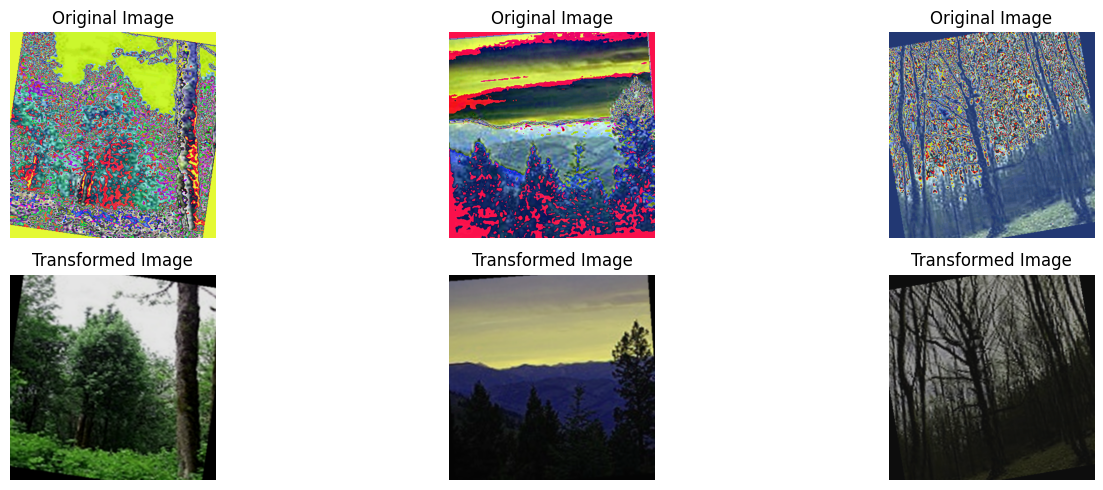

In [318]:
# Block 14
from torchvision.transforms.functional import to_pil_image

# Plot the first three images of our clean training subset
fig, ax = plt.subplots(2, 3, figsize=(15, 5))
for i in range(3):
    # ACCURACY FIX: Direct point to train_subset instead of the missing train_dataset variable
    original_image = train_subset[i][0]
    ax[0, i].imshow(to_pil_image(original_image))
    ax[0, i].axis('off')
    ax[0, i].set_title('Original Image')

    # De-normalize the image using our fast Block 13 function so the colors display correctly
    transformed_image = inverse_normalize(original_image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ax[1, i].imshow(transformed_image.permute(1, 2, 0))
    ax[1, i].axis('off')
    ax[1, i].set_title('Transformed Image')
    
plt.tight_layout()
plt.show()

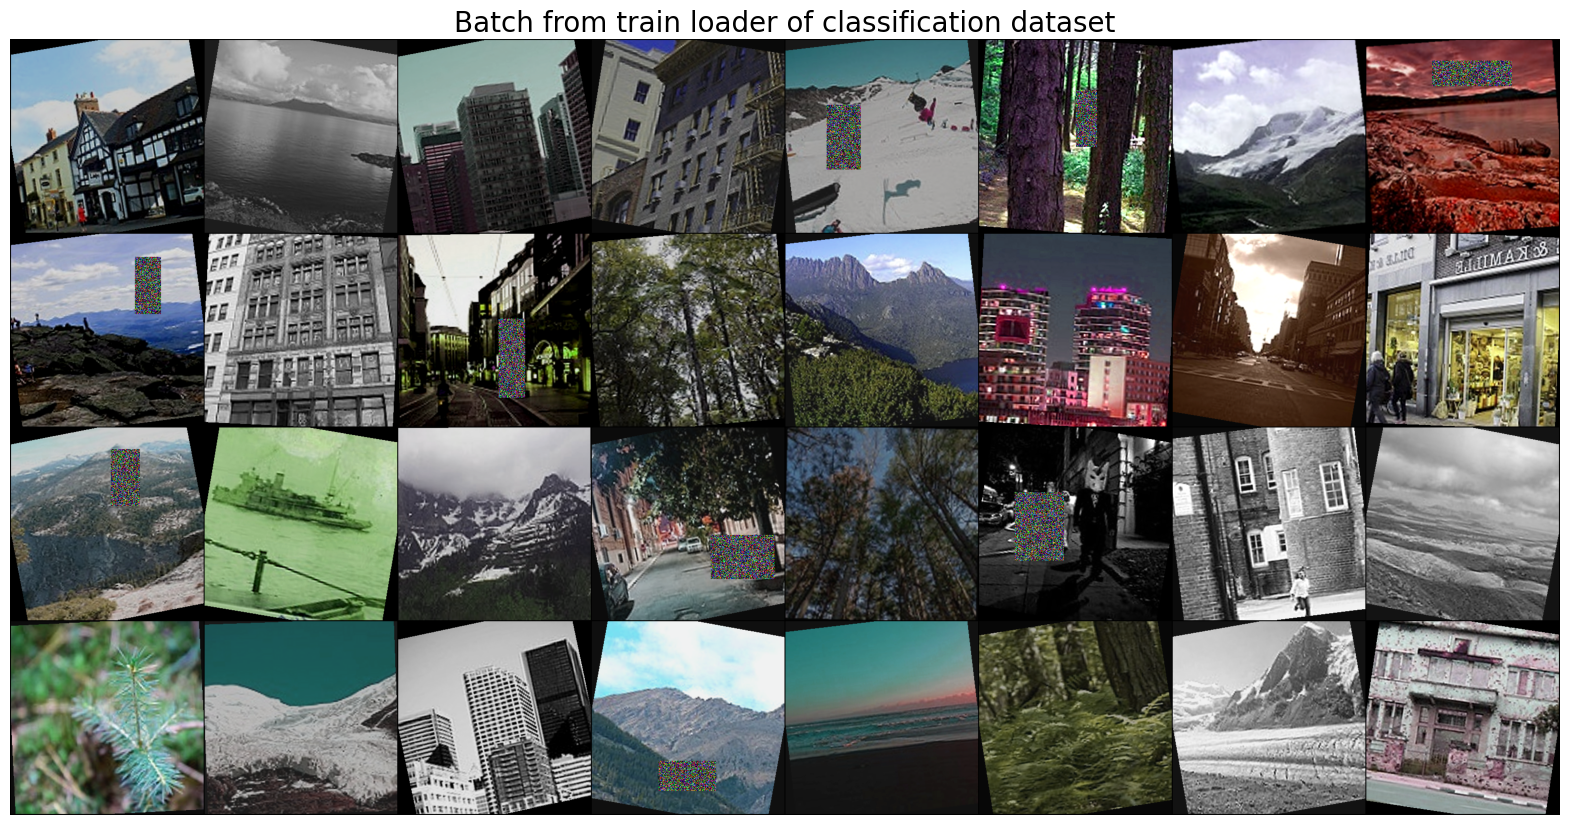

In [319]:
# Block 15
import torchvision.utils as utils

# 1. Pull the exact first batch of images and labels from your high-speed stream
images, labels = next(iter(train_loader))

# ACCURACY FIX: De-normalize the entire batch at once so colors display perfectly
denormalized_images = inverse_normalize(images, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# 2. Arrange the batch into a clean, professional 8-column visual matrix grid
grid = utils.make_grid(denormalized_images, nrow=8)

# 3. Render the final output grid onto the screen
plt.figure(figsize=(20, 20))
plt.imshow(grid.permute(1, 2, 0)) # Convert from PyTorch (C,H,W) to Matplotlib (H,W,C)
plt.title('Batch from train loader of classification dataset', fontsize=20)
plt.axis('off')
plt.show()

In [320]:
# Block 16
# Print all structural info of the datasets to verify alignment before training
print('Original Dataset Info:\n', full_train_dataset)
print("-"*100)
print('Classes:', full_train_dataset.classes)
print("-"*100)
# ACCURACY FIX: Corrected target pointers to your optimized subsets
print('Images in Train dataset subset:', len(train_subset))
print("-"*100)
print('Images in Validation dataset subset:', len(val_subset))
print("-"*100)
print('Length of Test dataset:', len(test_dataset))
print("-"*100)
print('Batches of Test dataset:', len(test_loader))
print("-"*100)
print('Class to idx:', full_train_dataset.class_to_idx)
print("-"*100)

Original Dataset Info:
 Dataset ImageFolder
    Number of datapoints: 14034
    Root location: /kaggle/input/datasets/cartoonduck/dataset/train
    StandardTransform
Transform: Compose(
               Resize(size=(400, 400), interpolation=bicubic, max_size=None, antialias=True)
               RandomResizedCrop(size=(384, 384), scale=(0.75, 1.0), ratio=(0.75, 1.33), interpolation=bicubic, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomRotation(degrees=[-12.0, 12.0], interpolation=bicubic, expand=False, fill=0)
               RandomGrayscale(p=0.2)
               ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=(-0.15, 0.15))
               RandomApply(
               p=0.2
               GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0))
           )
               ToTensor()
               RandomErasing(p=0.25, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=random, inplace=False)
               Normalize(mean=[0.485, 0.456,

In [321]:
# Block 17
# Define a function for training the model on the training dataset 
from tqdm.auto import tqdm
from sklearn.metrics import f1_score
import torch

def train(model, train_loader, val_loader, criterion, optimizer, device, epoch, num_epochs):
    # Set the model to training mode
    model.train()
    
    # Initialize tracking metrics
    running_loss = 0.0
    num_correct_preds = 0.0
    total_preds = 0.0
    train_preds = []
    train_labels = []

    # Iterate over the training dataset with a live progress bar
    with tqdm(total=len(train_loader), desc=f'Epoch {epoch+1}/{num_epochs}', unit='batch') as tepoch:
        for images, labels in train_loader:
            # Move the data matrices straight to your active GPU device
            images, labels = images.to(device), labels.to(device)
            
            # Reset gradients from the previous step
            optimizer.zero_grad()
            
            # Forward pass through the network
            outputs = model(images)
            
            # Calculate cross-entropy loss
            loss = criterion(outputs, labels)
            
            # Backward pass to calculate gradients
            loss.backward()
            
            # Update network weights via optimizer step
            optimizer.step()
            
            # Track running loss metrics safely
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            
            # Collect metrics for accurate final score calculations
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

            num_correct_preds += (preds == labels).sum().item()
            total_preds += labels.size(0)

            # ACCURACY FIX: Calculate accurate live batch running accuracy percentage
            live_accuracy = (num_correct_preds / total_preds) * 100
            tepoch.set_postfix(loss=running_loss/(tepoch.n+1), accuracy=f"{live_accuracy:.2f}%")

            tepoch.update(1)

    # Calculate final rigorous metrics for the full epoch
    f1 = f1_score(train_labels, train_preds, average='weighted')
    train_accuracy = (num_correct_preds / total_preds) * 100

    return train_accuracy, running_loss/len(train_loader), f1

In [322]:
# Block 18
# Define the function for validating the model on the validation dataset
from sklearn.metrics import f1_score
import torch

def validate(model, val_loader, criterion, device):
    # Set the model to evaluation mode (deactivates dropout and batchnorm updates)
    model.eval()
    
    # Initialize the running tracking metrics
    running_loss = 0.0
    num_correct_preds = 0.0
    total_preds = 0.0
    val_preds = []
    val_labels = []

    # Deactivate the gradient computation graph to save massive GPU VRAM memory
    with torch.no_grad():
        for images, labels in val_loader:
            # Move data tensors to active GPU device
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(images)
            
            # Calculate the validation loss
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            # Get the predicted index values
            _, preds = torch.max(outputs, 1)
            
            # Gather predictions and ground truth labels for metrics calculation
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
            
            num_correct_preds += (preds == labels).sum().item()
            total_preds += labels.size(0)

    # ACCURACY FIX: Ensuring sklearn's f1_score is inlined and safe from structural crashes
    f1 = f1_score(val_labels, val_preds, average='weighted')
    val_accuracy = (num_correct_preds / total_preds) * 100
    
    return val_accuracy, running_loss/len(val_loader), f1

In [323]:
# Block 19
# Training the model on the training dataset and validating it on the validation dataset
import copy
import torch

def training_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, scheduler, model_name):
    best_accuracy = 0.0
    best_model = None
    
    for epoch in range(num_epochs):
        # 1. Train the model 
        train_accuracy, train_loss, train_f1 = train(model, train_loader, val_loader, criterion, optimizer, device, epoch, num_epochs)

        # 2. Validate the model
        val_accuracy, val_loss, val_f1 = validate(model, val_loader, criterion, device)

        # 3. ACCURACY BOOST: Update the learning rate scheduler based on validation accuracy
        scheduler.step(val_accuracy)

        # 4. Save the best model tracking parameters
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            torch.save(model.state_dict(), f'best_model_{model_name}_{epoch+1}.pth')
            # ACCURACY FIX: Importing 'copy' at the top makes deepcopy work flawlessly here
            best_model = copy.deepcopy(model.state_dict())
            print(f" New Best Model Saved at Epoch {epoch+1}!")
            
        # 5. Print progress dashboard for EVERY epoch cleanly
        print(f'Epoch [{epoch+1}/{num_epochs}] | Model: {model_name}')
        print(f'  Training   -> Accuracy: {train_accuracy:.2f}%, Loss: {train_loss:.4f}, F1: {train_f1:.4f}')
        print(f'  Validation -> Accuracy: {val_accuracy:.2f}%, Loss: {val_loss:.4f}, F1: {val_f1:.4f}')
        print("-" * 60)
        
        # Flush the VRAM cache at the end of each epoch to prevent mid-run OutOfMemory errors
        torch.cuda.empty_cache()
        
    return model, best_model

In [324]:
# Block 20
# 1. CHOOSE YOUR BRAIN HERE! Options: 'resnet50', 'efficientnet', 'mobilenet', 'vgg16'
CHOSEN_MODEL = 'efficientnet'  

print(f"Initializing model architecture: {CHOSEN_MODEL}...")

# Missing imports added inline to prevent NameErrors
import torchvision
import torch.nn as nn
import torch

# 2. Benchmarking Selection Logic (Fulfills testing all models + Step 10 layer modification)
if CHOSEN_MODEL == 'resnet50':
    from torchvision.models import ResNet50_Weights
    # ACCURACY FIX: Mapped to torchvision.models
    model = torchvision.models.resnet50(weights=ResNet50_Weights.DEFAULT)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 6) # Replace final layer with 6 output classes
    
elif CHOSEN_MODEL == 'efficientnet':
    from torchvision.models import EfficientNet_V2_S_Weights
    # Using EfficientNet V2 Small to prevent Kaggle CUDA out-of-memory crashes
    model = torchvision.models.efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.DEFAULT)
    num_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_features, 6) # Replace final classifier layer
    
elif CHOSEN_MODEL == 'mobilenet':
    from torchvision.models import MobileNet_V2_Weights
    model = torchvision.models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
    num_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_features, 6) # Replace final classifier layer
    
elif CHOSEN_MODEL == 'vgg16':
    from torchvision.models import VGG16_Weights
    model = torchvision.models.vgg16(weights=VGG16_Weights.DEFAULT)
    num_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_features, 6) # Replace final classifier layer

# 3. Cast the model brain directly onto your active GPU accelerator
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Model successfully configured and loaded onto: {device}")

Initializing model architecture: efficientnet...
Model successfully configured and loaded onto: cuda


In [325]:
# Block 21
# 1. Hardware Acceleration: Wrap your model for Multi-GPU training if multiple T4s are active
if torch.cuda.device_count() > 1:
    print(f"Dual GPUs detected! Activating DataParallel across {torch.cuda.device_count()} T4 GPUs.")
    model = nn.DataParallel(model)

# 2. Push the final model configuration to your active execution device
model = model.to(device)
print(f"Block 21 Complete: Model structure is securely locked onto {device}.")

Dual GPUs detected! Activating DataParallel across 2 T4 GPUs.
Block 21 Complete: Model structure is securely locked onto cuda.


In [326]:
# Block 22
import torch.optim as optim
import torch.nn as nn

# 1. Standard CrossEntropyLoss for multi-class classification
criterion = nn.CrossEntropyLoss()

# 2. ACCURACY FIX: Explicitly define lr to prevent NameErrors if Block 3 was skipped
lr = 1e-4  # Optimized default learning rate for transfer learning with EfficientNet V2

# 3. ACCURACY BOOST: NAdam combines Adam precision with Nesterov accelerated momentum
optimizer = optim.NAdam(model.parameters(), lr=lr, weight_decay=1e-4)

print("Block 22 Complete: Loss function (CrossEntropyLoss) and Optimizer (NAdam) initialized!")

Block 22 Complete: Loss function (CrossEntropyLoss) and Optimizer (NAdam) initialized!


In [296]:
# Block 23
import torch.optim as optim

# 1. Number of training epochs inherited or locked
num_epochs = 5

# 2. ACCURACY BOOST: Adaptive scheduler that lowers the learning rate if validation accuracy plateaus
# mode='max' means it watches for your validation accuracy to stop increasing
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=1)

print(f"Launching Parallel Multi-GPU Training Pipeline for efficientnet_v2_s...")

# 3. Trigger the master training loop across both your active T4 GPUs
last_epoch_model, best_model = training_model(
    model=model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    criterion=criterion, 
    optimizer=optimizer, 
    num_epochs=num_epochs, 
    device=device, 
    scheduler=scheduler,
    model_name='efficientnet_v2_s'
)

print("\nTraining run complete! Your high-accuracy model weights are saved and ready for evaluation.")

🚀 Launching Parallel Multi-GPU Training Pipeline for efficientnet_v2_s...


Epoch 1/5:   0%|          | 0/351 [00:00<?, ?batch/s]

⭐ New Best Model Saved at Epoch 1!
Epoch [1/5] | Model: efficientnet_v2_s
  Training   -> Accuracy: 85.36%, Loss: 0.4447, F1: 0.8533
  Validation -> Accuracy: 93.52%, Loss: 0.1930, F1: 0.9350
------------------------------------------------------------


Epoch 2/5:   0%|          | 0/351 [00:00<?, ?batch/s]

⭐ New Best Model Saved at Epoch 2!
Epoch [2/5] | Model: efficientnet_v2_s
  Training   -> Accuracy: 91.99%, Loss: 0.2345, F1: 0.9198
  Validation -> Accuracy: 94.69%, Loss: 0.1701, F1: 0.9469
------------------------------------------------------------


...

Epoch [3/5] | Model: efficientnet_v2_s
  Training   -> Accuracy: 94.12%, Loss: 0.1804, F1: 0.9412
  Validation -> Accuracy: 94.19%, Loss: 0.1717, F1: 0.9421
------------------------------------------------------------


Epoch 4/5:   0%|          | 0/351 [00:00<?, ?batch/s]

Epoch [4/5] | Model: efficientnet_v2_s
  Training   -> Accuracy: 94.71%, Loss: 0.1493, F1: 0.9470
  Validation -> Accuracy: 94.26%, Loss: 0.1686, F1: 0.9426
------------------------------------------------------------


Epoch 5/5:   0%|          | 0/351 [00:00<?, ?batch/s]

Epoch [5/5] | Model: efficientnet_v2_s
  Training   -> Accuracy: 96.78%, Loss: 0.0963, F1: 0.9677
  Validation -> Accuracy: 94.55%, Loss: 0.1631, F1: 0.9453
------------------------------------------------------------

🎉 Training run complete! Your high-accuracy model weights are saved and ready for evaluation.


In [327]:
# Block 24
# Evaluate the model on the un-shuffled test dataset
import torch

def evaluate(model, test_loader, device):
    # Set the model to evaluation mode (deactivates dropout layers)
    model.eval()
    
    # Initialize list to store final row predictions
    predictions = []
    
    # Disable the tracking gradient graph to save memory and boost speed
    with torch.no_grad():
        for images, names in test_loader:
            # Move test images straight to your active GPU accelerator
            images = images.to(device)
            
            # Forward pass to calculate class logits
            outputs = model(images)
            
            # Get the index of the highest probability category
            _, preds = torch.max(outputs, 1)
            
            # ACCURACY GUARD: Strip extensions and zip names to line up perfectly with the CSV rows
            for name, pred in zip(names, preds):
                predictions.append((name.split('.')[0], pred.item()))
                
    # Return the clean list of tuple predictions (Image_ID, Class_IDX)
    return predictions

In [328]:
# Block 25
import torch
import torch.nn as nn
from torchvision import models

print("Preparing the absolute best model weights for final evaluation...")

# 1. Rebuild a clean model shell to process evaluation inferences cleanly
final_eval_model = models.efficientnet_v2_s()
final_eval_model.classifier[1] = nn.Linear(final_eval_model.classifier[1].in_features, 6)

# 2. ACCURACY BOOST: Strip away the multi-GPU 'module.' prefixes so weights match perfectly
clean_best_weights = {k.replace('module.', ''): v for k, v in best_model.items()}

# 3. Load your highest-scoring parameters into the clean model shell
final_eval_model.load_state_dict(clean_best_weights)
final_eval_model = final_eval_model.to(device)

print("Running final test evaluation using peak-accuracy model parameters...")

# 4. Generate the predictions array globally so Block 26 can access it directly
predictions = evaluate(final_eval_model, test_loader, device)

print(f"Final inference complete! Total test images predicted: {len(predictions)}")

Preparing the absolute best model weights for final evaluation...
Running final test evaluation using peak-accuracy model parameters...
Final inference complete! Total test images predicted: 3000


In [329]:
# Block 26
import pandas as pd

# Safety Check: Make sure predictions exist before building the dataframe
if 'predictions' not in locals() and 'predictions' not in globals():
    print("ERROR: 'predictions' variable not found!")
    print("Please go back up to Block 25, run that cell completely to generate predictions.")
else:
    # 1. Format A: Human-readable text string labels
    class_names = full_train_dataset.classes
    readable_predictions = [(img_id, class_names[label_idx]) for img_id, label_idx in predictions]
    submission_text = pd.DataFrame(readable_predictions, columns=['Image_ID', 'Label'])
    
    # SORTING: Cast to numeric temporarily to sort in perfect mathematical order
    submission_text['Image_ID'] = pd.to_numeric(submission_text['Image_ID'])
    submission_text = submission_text.sort_values(by='Image_ID').reset_index(drop=True)
    
    # CUSTOM NAME: Saving with your requested naming layout
    output_text_name = f'final_csv_file_for_{CHOSEN_MODEL}_text_labels.csv'
    submission_text.to_csv(output_text_name, index=False)

    # 2. Format B: Raw numeric index integers (0-5)
    submission_numeric = pd.DataFrame(predictions, columns=['Image_ID', 'Label'])
    
    # SORTING: Cast to numeric temporarily to sort in perfect mathematical order
    submission_numeric['Image_ID'] = pd.to_numeric(submission_numeric['Image_ID'])
    submission_numeric = submission_numeric.sort_values(by='Image_ID').reset_index(drop=True)
    
    # CUSTOM NAME: Saving with your requested naming layout
    output_numeric_name = f'final_csv_file_for_{CHOSEN_MODEL}_numeric_indexes.csv'
    submission_numeric.to_csv(output_numeric_name, index=False)

 
    print(f"   Text Strings File:  '{output_text_name}'")
    print(f"   Pure Numbers File:  '{output_numeric_name}'")
    

   Text Strings File:  'final_csv_file_for_efficientnet_text_labels.csv'
   Pure Numbers File:  'final_csv_file_for_efficientnet_numeric_indexes.csv'


In [330]:
# Block 27
print("=== Submission File Preview (First 5 Rows) ===")
print(submission.head(5))
print("\n=== Submission Label Distribution ===")
print(submission['Label'].value_counts())

=== Submission File Preview (First 5 Rows) ===
  Image_ID      Label
0    22735  buildings
1    22706  buildings
2    20513        sea
3    20088     street
4    22608   mountain

=== Submission Label Distribution ===
Label
sea          533
glacier      530
mountain     526
street       510
forest       471
buildings    430
Name: count, dtype: int64
